In [20]:
import pandas as pd

In [21]:
!wget -O kite_example_data.xlsx https://tinyurl.com/kite-data

--2026-07-21 14:22:19--  https://tinyurl.com/kite-data
Resolving tinyurl.com (tinyurl.com)... 104.17.112.233, 104.18.111.161, 2606:4700::6812:6fa1, ...
Connecting to tinyurl.com (tinyurl.com)|104.17.112.233|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://drive.google.com/uc?export=download&id=1YkaylwpM9EuEjKiXB42U-fs4yHZQBDAQ [following]
--2026-07-21 14:22:19--  https://drive.google.com/uc?export=download&id=1YkaylwpM9EuEjKiXB42U-fs4yHZQBDAQ
Resolving drive.google.com (drive.google.com)... 172.253.155.101, 172.253.155.139, 172.253.155.113, ...
Connecting to drive.google.com (drive.google.com)|172.253.155.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1YkaylwpM9EuEjKiXB42U-fs4yHZQBDAQ&export=download [following]
--2026-07-21 14:22:19--  https://drive.usercontent.google.com/download?id=1YkaylwpM9EuEjKiXB42U-fs4yHZQBDAQ&export=download
Resolving drive

In [22]:
!wget -O "Board Network datasets.xlsx" https://tinyurl.com/board-data

--2026-07-21 14:22:20--  https://tinyurl.com/board-data
Resolving tinyurl.com (tinyurl.com)... 104.17.112.233, 104.18.111.161, 2606:4700::6812:6fa1, ...
Connecting to tinyurl.com (tinyurl.com)|104.17.112.233|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://drive.google.com/uc?export=download&id=1nsPqP-yJMm5lnkJqzG_6ZyPSoy2HtvbE [following]
--2026-07-21 14:22:20--  https://drive.google.com/uc?export=download&id=1nsPqP-yJMm5lnkJqzG_6ZyPSoy2HtvbE
Resolving drive.google.com (drive.google.com)... 172.253.155.101, 172.253.155.139, 172.253.155.113, ...
Connecting to drive.google.com (drive.google.com)|172.253.155.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1nsPqP-yJMm5lnkJqzG_6ZyPSoy2HtvbE&export=download [following]
--2026-07-21 14:22:20--  https://drive.usercontent.google.com/download?id=1nsPqP-yJMm5lnkJqzG_6ZyPSoy2HtvbE&export=download
Resolving driv

In [23]:
df = pd.read_excel("kite_example_data.xlsx", "Sheet1")

In [24]:
df.head()

,Source,Target
0,Andre,Beverly
1,Andre,Diane
2,Andre,Carol
3,Andre,Fernando
4,Beverly,Diane


In [25]:
df[["Source"]]

,Source
0,Andre
1,Andre
2,Andre
3,Andre
4,Beverly
5,Beverly
6,Beverly
7,Carol
8,Carol
9,Diane


In [26]:
andre_links = df.loc[df["Source"]=="Andre"]
andre_links.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Source  4 non-null      object
 1   Target  4 non-null      object
dtypes: object(2)
memory usage: 96.0+ bytes


In [27]:
df.iloc[5]

,5
Source,Beverly
Target,Ed


In [28]:
import networkx as nx
import matplotlib.pyplot as plt

In [29]:
G = nx.from_pandas_edgelist(df, "Source", "Target")

In [30]:
pos = nx.spring_layout(G, seed=42)

<function matplotlib.pyplot.draw() -> 'None'>

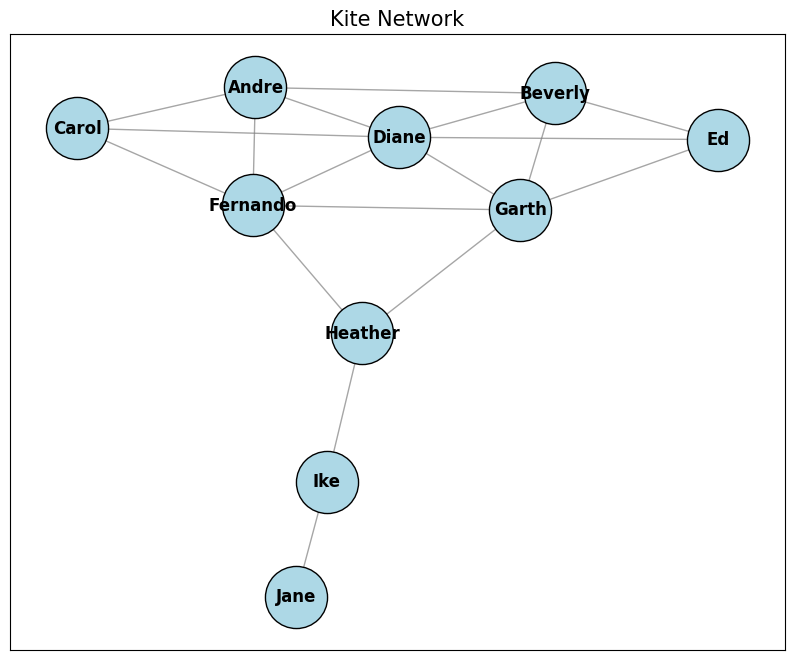

In [31]:
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(G,pos, node_size=2000, node_color="lightblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
plt.title("Kite Network", fontsize=15)
plt.savefig("kite_network.png")
plt.draw

In [32]:
b = nx.betweenness_centrality(G,normalized=False)
b

{'Andre': 0.8333333333333333,
 'Beverly': 0.8333333333333333,
 'Diane': 3.6666666666666665,
 'Carol': 0.0,
 'Fernando': 8.333333333333334,
 'Ed': 0.0,
 'Garth': 8.333333333333334,
 'Heather': 14.0,
 'Ike': 8.0,
 'Jane': 0.0}

In [33]:
pd.Series(b, name="Betweenness").sort_values(ascending=False)

,Betweenness
Heather,14.000000
Fernando,8.333333
Garth,8.333333
Ike,8.000000
Diane,3.666667
Andre,0.833333
Beverly,0.833333
Carol,0.000000
Ed,0.000000
Jane,0.000000


<function matplotlib.pyplot.draw() -> 'None'>

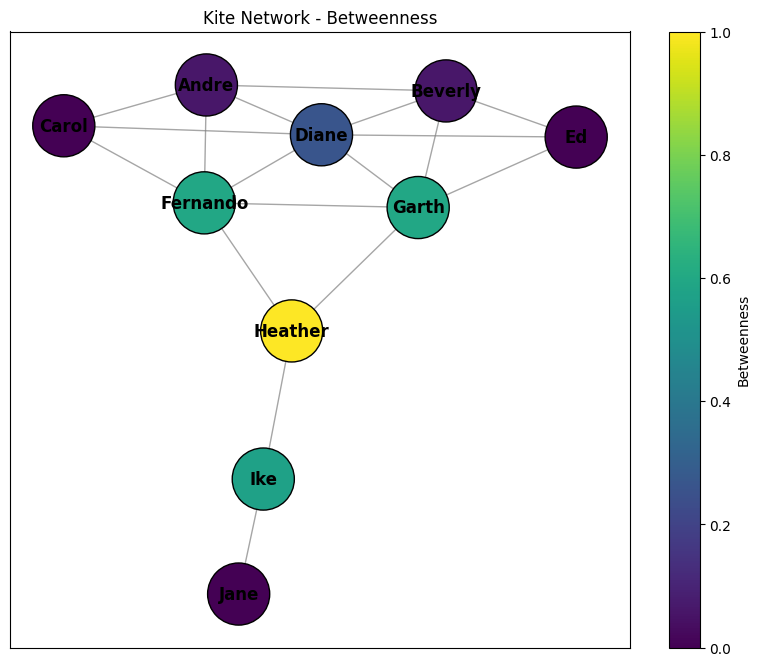

In [34]:
def color_centrality_graph(G, label, d_in):
  fig, ax = plt.subplots(figsize=(10,8))
  node_colors = [d_in[node] for node in G.nodes()]
  nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=node_colors, cmap=plt.cm.viridis, edgecolors="black")
  nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.7)
  nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
  plt.title(f"Kite Network - {label}")
  plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), ax=ax, label=label)
  return(plt)

color_centrality_graph(G, "Betweenness", b).draw

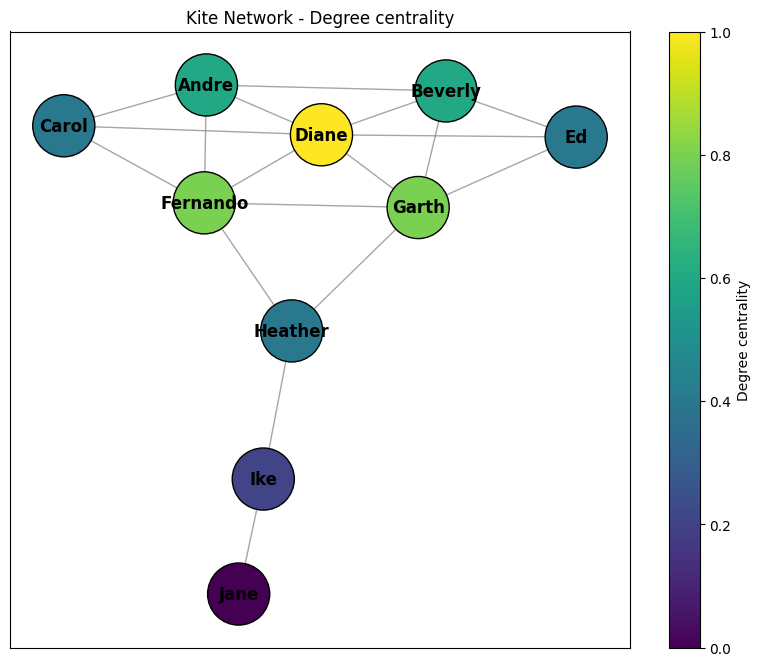

In [35]:
d = nx.degree_centrality(G)
color_centrality_graph(G, "Degree centrality", d).draw()

<function matplotlib.pyplot.draw() -> 'None'>

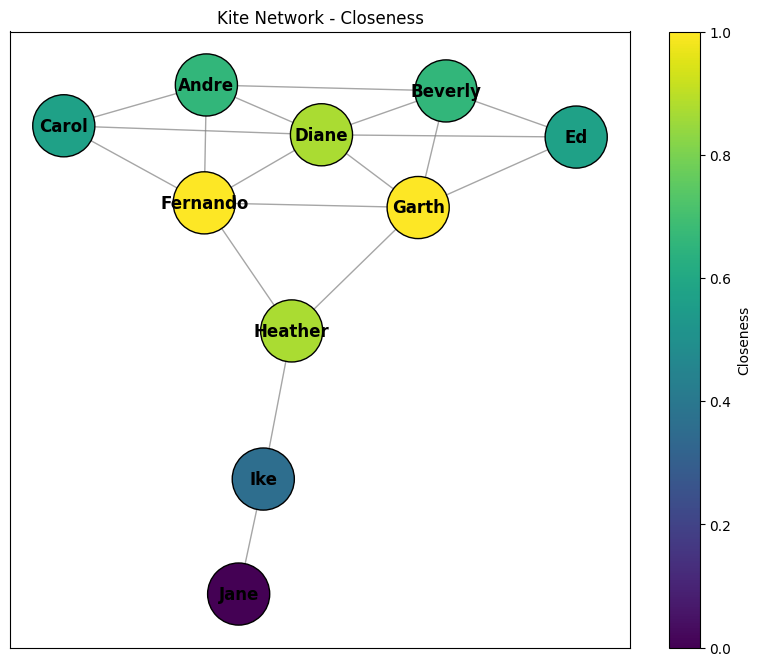

In [36]:
c = nx.closeness_centrality(G)
color_centrality_graph(G, "Closeness", c).draw

<function matplotlib.pyplot.draw() -> 'None'>

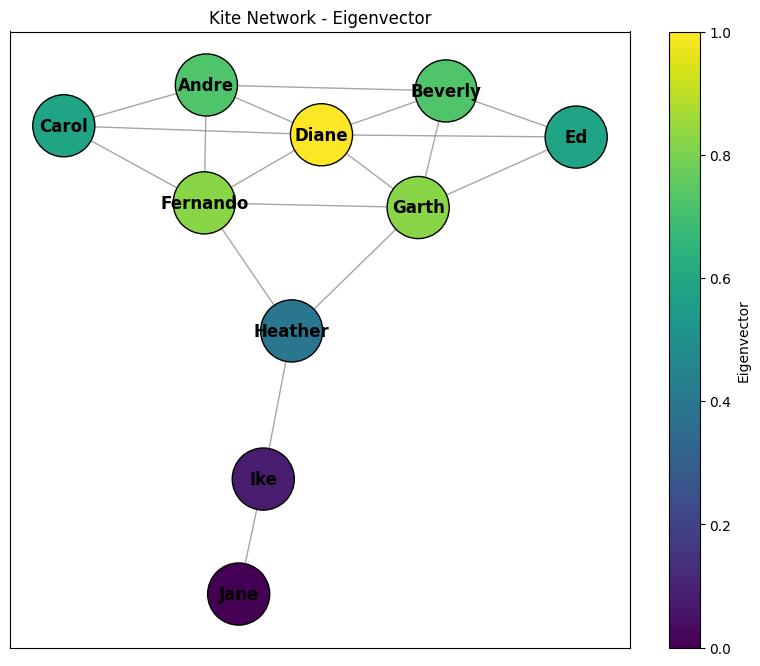

In [37]:
e = nx.eigenvector_centrality(G)
color_centrality_graph(G, "Eigenvector", e).draw